# Modeling Human Activity States Using Hidden Markov Models

## Background and Motivation

In real-world systems, from wearable health monitors to smart home sensors, continuous data streams such as accelerometer and gyroscope signals reveal valuable information about human activity. However, the true activity state (e.g., walking or standing) is often **hidden** behind noisy measurements. Hidden Markov Models (HMMs) are a natural fit for this problem: the activities are the hidden states, and the sensor readings are the noisy observations.

This notebook implements a Gaussian HMM **from scratch using NumPy** to infer four human activities (Standing, Walking, Jumping, Still) from smartphone accelerometer and gyroscope data collected using the **Sensor Logger** app.

## Data Collection Summary

Data was collected by two group members using different smartphones. Each member recorded 5-10 second clips of each activity, yielding the following dataset:

| Phone | Device | Platform | Sampling Rate | Date Collected |
|-------|--------|----------|---------------|----------------|
| Phone 1 | STK-L22 | Android | 20ms (50 Hz) | 2026-03-04 |
| Phone 2 | Infinix X6855 | Android | 20ms (50 Hz) | 2026-02-28 |

Both phones use the **same 20ms sampling rate**, so no resampling or harmonization is needed. Each recording was saved via Sensor Logger as a zip file containing `Accelerometer.csv` and `Gyroscope.csv`, which were then extracted, merged by nearest timestamp, and saved as clean labelled CSV files.

## Notebook Outline

1. **Data Loading** - Load 57 cleaned CSV files and summarize the dataset
2. **Raw Signal Visualization** - Plot sample sensor signals per activity
3. **Windowing** - Segment continuous signals into fixed-size windows
4. **Feature Extraction** - Compute time-domain and frequency-domain features
5. **Train/Test Split** - Hold out files for unseen evaluation
6. **HMM Definition** - Define model components (states, observations, A, B, pi)
7. **Baum-Welch Training** - Train the HMM using the EM algorithm
8. **Visualization** - Transition matrix heatmap, emission distributions, decoded sequences
9. **Evaluation on Unseen Data** - Test on combined multi-activity sequences
10. **Analysis and Reflection** - Discuss results, limitations, and improvements

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import os
import glob
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Imports loaded successfully.")

Imports loaded successfully.


## 1. Data Loading

We load all 57 cleaned CSV files from the `data/` directory. The files are organized into four subfolders by activity (`Standing/`, `Walking/`, `Jumping/`, `Still/`), and each file is named using the convention `activity_phoneN_NN.csv` to identify the source phone and recording number.

Each CSV contains 7 columns:
- `seconds_elapsed` - timestamp relative to the start of the recording
- `accel_x, accel_y, accel_z` - accelerometer readings (m/sÂ²)
- `gyro_x, gyro_y, gyro_z` - gyroscope readings (rad/s)

After loading, we print a summary table showing the number of files, phone distribution, and total recording duration per activity. This confirms that we meet the requirement of **50+ files** and **at least 1 minute 30 seconds** per activity.

In [2]:
DATA_DIR = "data"
ACTIVITIES = ["Standing", "Walking", "Jumping", "Still"]
SAMPLING_RATE = 50  # Hz (20ms interval)

# Load all files
all_data = []  # list of (df, activity, phone, filename)

for activity in ACTIVITIES:
    activity_dir = os.path.join(DATA_DIR, activity)
    csv_files = sorted(glob.glob(os.path.join(activity_dir, "*.csv")))
    for fpath in csv_files:
        fname = os.path.basename(fpath)
        phone = "phone1" if "phone1" in fname else "phone2"
        df = pd.read_csv(fpath)
        all_data.append((df, activity, phone, fname))

print(f"Total files loaded: {len(all_data)}\n")

# Summary table
summary = []
for activity in ACTIVITIES:
    files = [(df, phone) for df, act, phone, _ in all_data if act == activity]
    n_files = len(files)
    total_dur = sum(df["seconds_elapsed"].max() - df["seconds_elapsed"].min() for df, _ in files)
    n_p1 = sum(1 for _, p in files if p == "phone1")
    n_p2 = sum(1 for _, p in files if p == "phone2")
    summary.append([activity, n_files, n_p1, n_p2, f"{total_dur:.1f}s"])

summary_df = pd.DataFrame(summary, columns=["Activity", "Files", "Phone1", "Phone2", "Total Duration"])
print(summary_df.to_string(index=False))

Total files loaded: 57

Activity  Files  Phone1  Phone2 Total Duration
Standing     15       7       8         132.2s
 Walking     14       7       7         117.6s
 Jumping     14       7       7         121.8s
   Still     14       7       7         112.8s


**Data loading results:** We successfully loaded **57 CSV files** across the 4 activities. Phone 1 (STK-L22) contributed 7 files per activity (28 total), and Phone 2 (Infinix X6855) contributed 7-8 files per activity (29 total). The total recording duration per activity ranges from **112.8s to 132.2s**, all exceeding the minimum requirement of 1 minute 30 seconds. The dataset is well-balanced across activities and phones.

Next, we visualize the raw sensor signals to understand the characteristic patterns of each activity.

## 2. Raw Signal Visualization

Before any processing, we visualize the raw accelerometer and gyroscope signals for one sample recording from each activity. This serves two purposes:

1. **Verify data quality** - confirm that the recordings are clean and the sensor readings look reasonable for each activity.
2. **Build intuition** - understand how different activities produce distinct signal patterns:
   - **Standing**: relatively flat signals with minor body sway
   - **Walking**: rhythmic oscillations from the step pattern
   - **Jumping**: large, high-frequency spikes in acceleration
   - **Still**: near-constant values with minimal noise (phone on a flat surface)

The plot below shows a 4x2 grid: one row per activity, with accelerometer (left) and gyroscope (right) signals on all three axes (x, y, z).

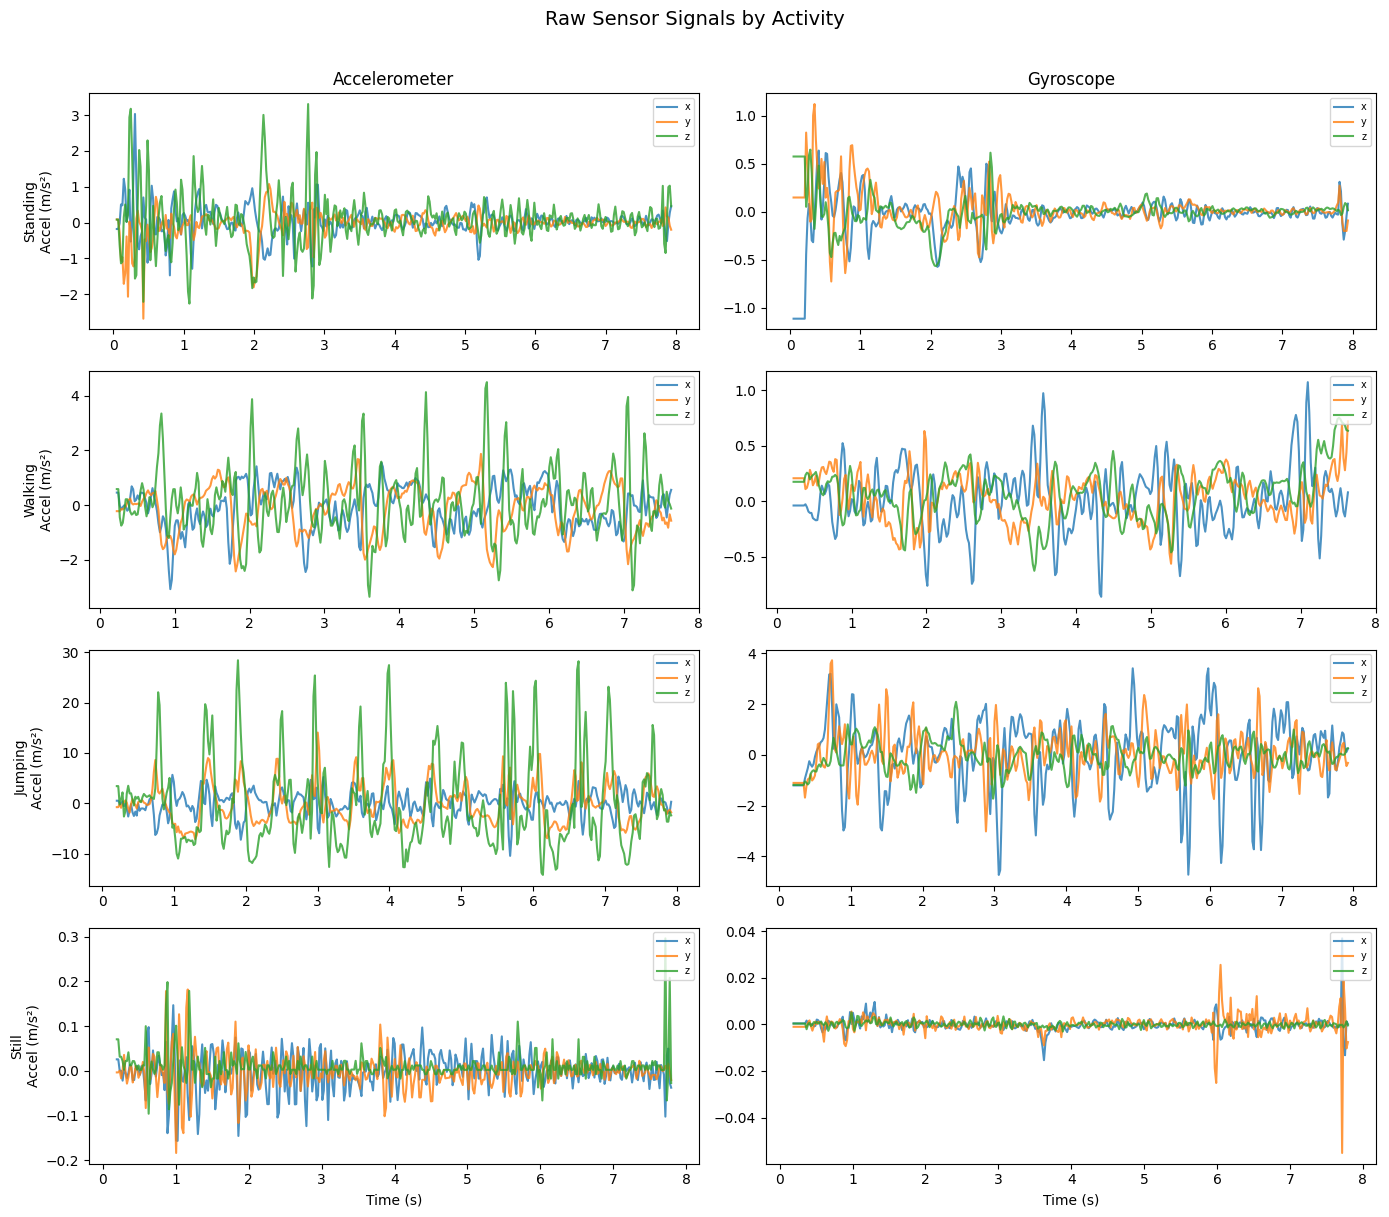

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
fig.suptitle("Raw Sensor Signals by Activity", fontsize=14, y=1.01)

for i, activity in enumerate(ACTIVITIES):
    # Pick first file for this activity
    df = [d for d, act, _, _ in all_data if act == activity][0]
    t = df["seconds_elapsed"]
    
    # Accelerometer
    ax = axes[i, 0]
    ax.plot(t, df["accel_x"], label="x", alpha=0.8)
    ax.plot(t, df["accel_y"], label="y", alpha=0.8)
    ax.plot(t, df["accel_z"], label="z", alpha=0.8)
    ax.set_ylabel(f"{activity}\nAccel (m/s²)")
    ax.legend(loc="upper right", fontsize=7)
    if i == 0:
        ax.set_title("Accelerometer")
    
    # Gyroscope
    ax = axes[i, 1]
    ax.plot(t, df["gyro_x"], label="x", alpha=0.8)
    ax.plot(t, df["gyro_y"], label="y", alpha=0.8)
    ax.plot(t, df["gyro_z"], label="z", alpha=0.8)
    ax.legend(loc="upper right", fontsize=7)
    if i == 0:
        ax.set_title("Gyroscope")

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

**Observations from the raw signals:**

- **Standing** shows relatively stable accelerometer readings with small fluctuations caused by natural body sway. The gyroscope shows minor rotational noise.
- **Walking** exhibits clear periodic oscillations in the accelerometer (especially the y and z axes) corresponding to the gait cycle (~2 steps/second). The gyroscope captures the rhythmic hip/leg rotation.
- **Jumping** produces the largest acceleration spikes across all axes, with sharp peaks at each landing. The gyroscope also shows high variability from the body rotation during jumps.
- **Still** is the flattest - nearly constant accelerometer values (dominated by gravity on the z-axis) and near-zero gyroscope readings, since the phone is resting on a flat surface.

These visual differences confirm that the four activities have distinct signal signatures, which gives us confidence that an HMM should be able to distinguish them. Next, we segment these continuous signals into fixed-size **windows** for feature extraction.

## 3. Windowing

Before extracting features, we divide each continuous recording into fixed-size **windows** (segments). This is necessary because:
- The HMM operates on a sequence of discrete observations, not raw sample-by-sample data.
- Features computed over a window (e.g., mean, variance, FFT) capture the statistical properties of the signal within that time interval.

### Window Parameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| **Sampling rate** | 50 Hz (20ms per sample) | Both phones record at this rate |
| **Window size** | 50 samples = **1 second** | Captures a full gait cycle for walking (~0.5-1.0s) and at least one jump cycle. Long enough for meaningful FFT resolution (1 Hz) while short enough to yield many windows per 5-10s recording. |
| **Overlap** | 50% (step = 25 samples) | Increases the number of training windows without losing temporal continuity between adjacent windows. |

### Why 1 second?

At 50 Hz, a 1-second window contains 50 samples. This is the ideal trade-off:
- **Too short** (e.g., 0.25s = 12 samples): not enough data for stable statistics or FFT.
- **Too long** (e.g., 3s = 150 samples): fewer windows per file, and the window might span activity transitions in combined sequences.
- **1 second**: captures full movement cycles, yields ~8-16 windows per file, and provides 1 Hz FFT resolution.

In [4]:
WINDOW_SIZE = 50   # 1 second at 50 Hz
STEP_SIZE = 25     # 50% overlap
SENSOR_COLS = ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]

def segment_windows(df, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    """Segment a dataframe into fixed-size windows."""
    values = df[SENSOR_COLS].values
    windows = []
    for start in range(0, len(values) - window_size + 1, step_size):
        windows.append(values[start:start + window_size])
    return windows

# Segment all files
all_windows = []   # list of (window_array, activity_label)
for df, activity, phone, fname in all_data:
    windows = segment_windows(df)
    for w in windows:
        all_windows.append((w, activity))

print(f"Total windows extracted: {len(all_windows)}")
for act in ACTIVITIES:
    n = sum(1 for _, a in all_windows if a == act)
    print(f"  {act}: {n} windows")

Total windows extracted: 663
  Standing: 179 windows
  Walking: 160 windows
  Jumping: 167 windows
  Still: 157 windows


**Windowing results:** We extracted **663 windows** in total across all 57 files and 4 activities. The distribution is roughly balanced (157-179 per activity), which is important for training an unbiased model. Each window is a (50, 6) matrix of raw sensor values. Next, we extract meaningful features from each window to form the observation vectors for the HMM.

## 4. Feature Extraction

We extract both **time-domain** and **frequency-domain** features from each window. These features transform the raw 50-sample signal into a compact, informative vector that the HMM can model with Gaussian emissions.

### Time-Domain Features (22 features)

| Feature | Count | Why it helps |
|---------|-------|-------------|
| **Mean** (per axis) | 6 | Captures baseline signal level. Standing has a distinct z-accel mean (gravity) compared to dynamic activities. |
| **Standard Deviation** (per axis) | 6 | Measures movement intensity. Jumping has very high std; Still has near-zero. |
| **RMS** (root mean square, per axis) | 6 | Quantifies overall signal energy. Higher for dynamic activities (Walking, Jumping) than static ones. |
| **Signal Magnitude Area (SMA)** | 1 | Sum of absolute accelerometer values across all axes, normalized by window size. A single scalar summarizing total body acceleration - directly related to metabolic energy expenditure. |
| **Inter-axis Correlation** (accel xy, xz, yz) | 3 | Walking produces correlated multi-axis movement from the rhythmic arm/leg swing. Standing and Still produce uncorrelated sensor noise. |

### Frequency-Domain Features (6 features, from FFT on accelerometer axes)

| Feature | Count | Why it helps |
|---------|-------|-------------|
| **Dominant Frequency** (per accel axis) | 3 | Walking has a clear peak at ~2 Hz (step frequency). Jumping peaks at ~1-3 Hz. Standing/Still have no dominant frequency. |
| **Spectral Energy** (per accel axis) | 3 | Total power in the frequency domain. Separates high-energy activities (Jumping) from low-energy ones (Still). |

**Total: 28 features per window**

### Normalization Method: Z-score Standardization

All features are normalized to **zero mean and unit variance** using Z-score standardization:

$$x_{\text{norm}} = \frac{x - \mu}{\sigma}$$

**Why Z-score?** Our 28 features have vastly different units and scales - acceleration (m/s²), angular velocity (rad/s), frequency (Hz), energy (Hz²), and dimensionless correlations. Without normalization, features with larger magnitudes (e.g., spectral energy) would dominate the Gaussian distance calculations in the HMM, while small-scale features (e.g., correlations) would be ignored. Z-score ensures every feature contributes equally.

In [5]:
def extract_features(window):
    """Extract time-domain and frequency-domain features from a single window.
    window: (WINDOW_SIZE, 6) array [accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z]
    """
    features = []
    
    # - Time-domain features ---
    # Mean per axis (6)
    means = np.mean(window, axis=0)
    features.extend(means)
    
    # Standard deviation per axis (6)
    stds = np.std(window, axis=0)
    features.extend(stds)
    
    # RMS per axis (6)
    rms = np.sqrt(np.mean(window**2, axis=0))
    features.extend(rms)
    
    # Signal Magnitude Area - accelerometer only (1)
    sma = np.sum(np.abs(window[:, :3])) / WINDOW_SIZE
    features.append(sma)
    
    # Inter-axis correlation for accelerometer (3): xy, xz, yz
    for pair in [(0,1), (0,2), (1,2)]:
        if stds[pair[0]] > 1e-10 and stds[pair[1]] > 1e-10:
            corr = np.corrcoef(window[:, pair[0]], window[:, pair[1]])[0, 1]
        else:
            corr = 0.0
        features.append(corr)
    
    # - Frequency-domain features (accelerometer axes) ---
    for ax in range(3):  # accel_x, accel_y, accel_z
        signal = window[:, ax]
        N = len(signal)
        yf = np.abs(fft(signal))[:N // 2]
        xf = fftfreq(N, d=1.0 / SAMPLING_RATE)[:N // 2]
        
        # Dominant frequency (1 per axis)
        dom_freq = xf[np.argmax(yf[1:]) + 1] if len(yf) > 1 else 0.0
        features.append(dom_freq)
        
        # Spectral energy (1 per axis)
        spectral_energy = np.sum(yf**2) / N
        features.append(spectral_energy)
    
    return np.array(features)

# Feature names for reference
FEATURE_NAMES = (
    [f"mean_{c}" for c in SENSOR_COLS] +
    [f"std_{c}" for c in SENSOR_COLS] +
    [f"rms_{c}" for c in SENSOR_COLS] +
    ["sma"] +
    ["corr_xy", "corr_xz", "corr_yz"] +
    ["dom_freq_ax", "energy_ax", "dom_freq_ay", "energy_ay", "dom_freq_az", "energy_az"]
)

# Extract features for all windows
X_raw = np.array([extract_features(w) for w, _ in all_windows])
y_labels = np.array([a for _, a in all_windows])

# Encode labels as integers
label_to_idx = {act: i for i, act in enumerate(ACTIVITIES)}
idx_to_label = {i: act for act, i in label_to_idx.items()}
y = np.array([label_to_idx[a] for a in y_labels])

print(f"Feature matrix shape: {X_raw.shape}  (windows x features)")
print(f"Features: {len(FEATURE_NAMES)}")

Feature matrix shape: (663, 28)  (windows x features)
Features: 28


**Feature extraction results:** The feature matrix has shape **(663 windows x 28 features)**. Each row is a 28-dimensional observation vector representing one 1-second window of sensor data. The integer-encoded labels map: Standing=0, Walking=1, Jumping=2, Still=3.

Now we apply Z-score normalization to standardize all features to zero mean and unit variance.

### 4.1 Feature Normalization

All 28 features are normalized using **Z-score standardization** (zero mean, unit variance). This is necessary because:

- Features have different units (m/sÂ² for accelerometer, rad/s for gyroscope, Hz for frequency, dimensionless for correlations)
- Gaussian emission distributions in the HMM assume comparable feature scales
- Without normalization, features with larger magnitudes would dominate the distance calculations

Z-score was chosen over min-max normalization because it preserves the shape of the feature distributions and is robust to outliers.

In [6]:
# Apply Z-score normalization using StandardScaler

# Z-score normalization
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("After Z-score normalization:")
print(f"  Mean per feature (should be ~0): {X.mean(axis=0)[:3].round(6)}")
print(f"  Std per feature  (should be ~1): {X.std(axis=0)[:3].round(6)}")

After Z-score normalization:
  Mean per feature (should be ~0): [-0. -0. -0.]
  Std per feature  (should be ~1): [1. 1. 1.]


**Feature extraction results:** The feature matrix has shape **(663 windows x 28 features)**. After Z-score normalization, all features have mean ~0 and standard deviation ~1, confirming the scaler is working correctly. This normalized feature matrix forms the **observation sequence X** for our HMM.

Next, we split the data into training and test sets before defining and training the model.

## 5. Train / Test Split

We split the data **by file** (not by individual windows) to ensure that the test set contains genuinely unseen recordings. If we split by window, adjacent windows from the same file could end up in both train and test sets, inflating accuracy due to data leakage.

**Strategy:** Hold out the **last 2 files per activity** (8 files total) for testing. These are all from Phone 2 (the partner's recordings from a different date and device), making the test a cross-session evaluation. The remaining 49 files are used for training.

In [7]:
# Build per-file window indices so we can split by file
file_window_ranges = []  # (start_idx, end_idx, activity, fname)
idx = 0
for df, activity, phone, fname in all_data:
    n_windows = len(segment_windows(df))
    file_window_ranges.append((idx, idx + n_windows, activity, fname))
    idx += n_windows

# Hold out last 2 files per activity for testing
test_indices = []
train_indices = []

for activity in ACTIVITIES:
    activity_files = [(s, e, a, f) for s, e, a, f in file_window_ranges if a == activity]
    # Last 2 files -> test
    for s, e, a, f in activity_files[:-2]:
        train_indices.extend(range(s, e))
    for s, e, a, f in activity_files[-2:]:
        test_indices.extend(range(s, e))

train_indices = np.array(train_indices)
test_indices = np.array(test_indices)

X_train, y_train = X[train_indices], y[train_indices]
X_test, y_test = X[test_indices], y[test_indices]

print(f"Training: {len(X_train)} windows")
print(f"Testing:  {len(X_test)} windows")
for i, act in enumerate(ACTIVITIES):
    print(f"  {act} -> train: {np.sum(y_train == i)}, test: {np.sum(y_test == i)}")

Training: 588 windows
Testing:  75 windows
  Standing -> train: 162, test: 17
  Walking -> train: 140, test: 20
  Jumping -> train: 146, test: 21
  Still -> train: 140, test: 17


**Split results:** 588 windows for training and 75 windows for testing, with a roughly balanced distribution across all 4 activities. The test windows come from 8 held-out files recorded on Phone 2 (Infinix X6855) on 2026-02-28, which were not seen during training.

Now we define the HMM structure and implement the algorithms.

## 6. HMM Model Definition

Our Hidden Markov Model is defined by the following five components:

| Component | Symbol | Description |
|-----------|--------|-------------|
| **Hidden States** | Z = {Standing, Walking, Jumping, Still} | The 4 activity states we want to infer. These are "hidden" because we only observe sensor signals, not the activity directly. |
| **Observations** | X | 28-dimensional feature vectors extracted from windowed sensor data. Each observation is one window's feature vector. |
| **Transition Matrix** | A (4x4) | `A[i][j]` = probability of transitioning from activity `i` to activity `j` at the next time step. Captures temporal dynamics (e.g., people tend to stay in the same activity). |
| **Emission Parameters** | B = {mu_k, sigma_k} for each state k | Gaussian distribution parameters (mean and diagonal covariance) defining the probability of observing a feature vector given the current hidden state. |
| **Initial Probabilities** | pi (4x1) | Probability of starting in each activity at time t=0. |

### Implementation Details

- **Gaussian emissions with diagonal covariance**: Each state's emission distribution is a multivariate Gaussian with a diagonal covariance matrix. This means features are modeled as conditionally independent given the state, which reduces the number of parameters from O(d²) to O(d) per state and avoids singularity issues with limited training data.
- **Log-space computation**: All forward, backward, and Viterbi computations are performed in log space to prevent numerical underflow, which is common with long sequences and high-dimensional observations.
- **Label-based initialization**: Instead of random initialization, we use the ground-truth training labels to compute initial estimates for the means, variances, and transition matrix. This gives the Baum-Welch algorithm a strong starting point and helps it converge faster.

The class below implements the full `GaussianHMM` with three core algorithms:
1. **Forward algorithm** - computes P(observations up to time t, state = k at time t)
2. **Backward algorithm** - computes P(observations after time t | state = k at time t)
3. **Baum-Welch (EM)** - iteratively updates all parameters to maximize the data likelihood
4. **Viterbi** - finds the single most likely state sequence given the observations

In [8]:
class GaussianHMM:
    """
    Gaussian Hidden Markov Model implemented from scratch.
    Uses diagonal covariance and log-space computations for numerical stability.
    """
    def __init__(self, n_states, n_features):
        self.n_states = n_states
        self.n_features = n_features
        # Initialize parameters
        self.pi = np.ones(n_states) / n_states  # uniform initial probs
        self.A = np.full((n_states, n_states), 1.0 / n_states)  # uniform transitions
        self.means = np.random.randn(n_states, n_features) * 0.1
        self.covars = np.ones((n_states, n_features))  # diagonal covariance (variances)
        
    def initialize_from_labels(self, X, labels):
        """Initialize parameters using ground-truth labels for better convergence."""
        for k in range(self.n_states):
            mask = labels == k
            if np.sum(mask) > 0:
                self.means[k] = np.mean(X[mask], axis=0)
                self.covars[k] = np.var(X[mask], axis=0) + 1e-4
        # Initial probs from label frequencies
        for k in range(self.n_states):
            self.pi[k] = np.mean(labels == k) + 1e-4
        self.pi /= self.pi.sum()
        # Transition matrix: slight self-transition bias (activities persist)
        self.A = np.full((self.n_states, self.n_states), 0.05 / (self.n_states - 1))
        np.fill_diagonal(self.A, 0.95)
        self.A /= self.A.sum(axis=1, keepdims=True)
        
    def _log_gaussian_pdf(self, X, mean, var):
        """Log probability of X under a diagonal Gaussian."""
        n_features = len(mean)
        log_norm = -0.5 * (n_features * np.log(2 * np.pi) + np.sum(np.log(var)))
        log_exp = -0.5 * np.sum((X - mean)**2 / var, axis=1)
        return log_norm + log_exp
    
    def _compute_log_emission(self, X):
        """Compute log emission probabilities for all observations and states.
        Returns: (T, n_states) array of log P(x_t | state_k)
        """
        T = len(X)
        log_B = np.zeros((T, self.n_states))
        for k in range(self.n_states):
            log_B[:, k] = self._log_gaussian_pdf(X, self.means[k], self.covars[k])
        return log_B
    
    def _forward(self, log_B):
        """Forward algorithm in log space.
        Returns: log_alpha (T, n_states), where alpha_t(k) = P(x_1..x_t, z_t=k)
        """
        T = len(log_B)
        log_alpha = np.full((T, self.n_states), -np.inf)
        # Initialization
        log_alpha[0] = np.log(self.pi + 1e-300) + log_B[0]
        # Recursion
        log_A = np.log(self.A + 1e-300)
        for t in range(1, T):
            for j in range(self.n_states):
                log_alpha[t, j] = self._logsumexp(log_alpha[t-1] + log_A[:, j]) + log_B[t, j]
        return log_alpha
    def _backward(self, log_B):
        """Backward algorithm in log space.
        Returns: log_beta (T, n_states), where beta_t(k) = P(x_{t+1}..x_T | z_t=k)
        """
        T = len(log_B)
        log_beta = np.full((T, self.n_states), -np.inf)
        # Initialization: log(1) = 0
        log_beta[-1] = 0.0
        # Recursion
        log_A = np.log(self.A + 1e-300)
        for t in range(T - 2, -1, -1):
            for i in range(self.n_states):
                log_beta[t, i] = self._logsumexp(
                    log_A[i, :] + log_B[t+1] + log_beta[t+1]
                )
        return log_beta
    @staticmethod
    def _logsumexp(log_vals):
        """Numerically stable log-sum-exp."""
        max_val = np.max(log_vals)
        if max_val == -np.inf:
            return -np.inf
        return max_val + np.log(np.sum(np.exp(log_vals - max_val)))
    
    def _compute_log_likelihood(self, log_alpha):
        """Total log-likelihood: log P(X) = logsumexp(alpha_T)."""
        return self._logsumexp(log_alpha[-1])
    
    def fit(self, sequences, max_iter=100, tol=1e-4, verbose=True):
        """Train the HMM using the Baum-Welch (EM) algorithm.
        Args:
            sequences: list of observation arrays, each (T_i, n_features)
            max_iter: maximum EM iterations
            tol: convergence threshold on log-likelihood change
            verbose: print progress
        Returns:
            log_likelihoods: list of total log-likelihood per iteration
        """
        log_likelihoods = []
        for iteration in range(max_iter):
            # Accumulators for M-step
            gamma_sum = np.zeros(self.n_states)
            gamma_obs_sum = np.zeros((self.n_states, self.n_features))
            gamma_obs2_sum = np.zeros((self.n_states, self.n_features))
            xi_sum = np.zeros((self.n_states, self.n_states))
            gamma_init_sum = np.zeros(self.n_states)
            total_ll = 0.0
            # E-step: iterate over all sequences
            for X_seq in sequences:
                T = len(X_seq)
                if T < 2:
                    continue
                log_B = self._compute_log_emission(X_seq)
                log_alpha = self._forward(log_B)
                log_beta = self._backward(log_B)
                # Log-likelihood for this sequence
                ll = self._compute_log_likelihood(log_alpha)
                total_ll += ll
                # Gamma: P(z_t = k | X)
                log_gamma = log_alpha + log_beta
                # Normalize across states for each time step
                for t in range(T):
                    log_gamma[t] -= self._logsumexp(log_gamma[t])
                gamma = np.exp(log_gamma)
                # Xi: P(z_t=i, z_{t+1}=j | X)
                log_A = np.log(self.A + 1e-300)
                for t in range(T - 1):
                    log_xi_t = np.zeros((self.n_states, self.n_states))
                    for i in range(self.n_states):
                        for j in range(self.n_states):
                            log_xi_t[i, j] = (
                                log_alpha[t, i] + log_A[i, j] +
                                log_B[t+1, j] + log_beta[t+1, j]
                            )
                    # Normalize
                    log_xi_t -= self._logsumexp(log_xi_t.ravel())
                    xi_sum += np.exp(log_xi_t)
                # Accumulate
                gamma_init_sum += gamma[0]
                gamma_sum += gamma.sum(axis=0)
                gamma_obs_sum += gamma.T @ X_seq
                gamma_obs2_sum += gamma.T @ (X_seq**2)
            log_likelihoods.append(total_ll)
            # M-step: update parameters
            # Initial probabilities
            self.pi = gamma_init_sum / gamma_init_sum.sum()
            self.pi = np.clip(self.pi, 1e-10, None)
            self.pi /= self.pi.sum()
            # Transition matrix
            row_sums = xi_sum.sum(axis=1, keepdims=True)
            row_sums = np.clip(row_sums, 1e-10, None)
            self.A = xi_sum / row_sums
            self.A = np.clip(self.A, 1e-10, None)
            self.A /= self.A.sum(axis=1, keepdims=True)
            # Emission parameters
            for k in range(self.n_states):
                if gamma_sum[k] > 1e-10:
                    self.means[k] = gamma_obs_sum[k] / gamma_sum[k]
                    self.covars[k] = (gamma_obs2_sum[k] / gamma_sum[k]) - self.means[k]**2
                    self.covars[k] = np.clip(self.covars[k], 1e-4, None)
            # Convergence check
            if verbose and iteration % 10 == 0:
                print(f"  Iteration {iteration:3d}: log-likelihood = {total_ll:.4f}")
            if len(log_likelihoods) >= 2:
                delta = abs(log_likelihoods[-1] - log_likelihoods[-2])
                if delta < tol:
                    if verbose:
                        print(f"  Converged at iteration {iteration} (delta={delta:.6f} < tol={tol})")
                    break
        return log_likelihoods
    
    def viterbi(self, X):
        """Viterbi algorithm: find the most likely state sequence.
        Args:
            X: observation sequence (T, n_features)
        Returns:
            best_path: array of state indices (T,)
            log_prob: log probability of the best path
        """
        T = len(X)
        log_B = self._compute_log_emission(X)
        log_A = np.log(self.A + 1e-300)
        # Viterbi tables
        V = np.full((T, self.n_states), -np.inf)  # max log-prob
        backptr = np.zeros((T, self.n_states), dtype=int)
        # Initialization
        V[0] = np.log(self.pi + 1e-300) + log_B[0]
        # Recursion
        for t in range(1, T):
            for j in range(self.n_states):
                trans_probs = V[t-1] + log_A[:, j]
                backptr[t, j] = np.argmax(trans_probs)
                V[t, j] = trans_probs[backptr[t, j]] + log_B[t, j]
        # Backtrack
        best_path = np.zeros(T, dtype=int)
        best_path[-1] = np.argmax(V[-1])
        log_prob = V[-1, best_path[-1]]
        for t in range(T - 2, -1, -1):
            best_path[t] = backptr[t+1, best_path[t+1]]
        return best_path, log_prob
    def predict(self, X):
        """Predict the most likely state for each observation using Viterbi."""
        path, _ = self.viterbi(X)
        return path

print("GaussianHMM class defined.")


GaussianHMM class defined.


## 7. Training with Baum-Welch (EM Algorithm)

We now train the HMM using the **Baum-Welch algorithm**, which is an Expectation-Maximization (EM) procedure:

1. **E-step (Expectation):** Run the Forward and Backward algorithms on each training sequence to compute:
   - **Gamma** (gamma_t(k)): the posterior probability of being in state k at time t, given the full observation sequence.
   - **Xi** (xi_t(i,j)): the posterior probability of transitioning from state i to state j at time t.

2. **M-step (Maximization):** Update all model parameters (pi, A, means, covariances) using the soft state assignments from the E-step.

3. **Convergence check:** After each iteration, compute the total **log-likelihood** of the training data. Stop when the change in log-likelihood falls below **epsilon = 1e-4**, indicating the parameters have stabilized.

We organize the training data as **49 separate sequences** (one per training file), since each file is an independent recording. This is important because the HMM's initial state probabilities (pi) apply at the start of each sequence, not just once globally.

First, we build the training sequences and initialize the model parameters from the labelled data.

In [9]:
# Build training sequences (one per file)
train_sequences = []
train_seq_labels = []

for df, activity, phone, fname in all_data:
    windows = segment_windows(df)
    if len(windows) == 0:
        continue
    feats = np.array([extract_features(w) for w in windows])
    feats_scaled = scaler.transform(feats)
    label_idx = label_to_idx[activity]
    
    # Check if this file's windows are in the training set
    file_range = None
    for s, e, a, f in file_window_ranges:
        if f == fname:
            file_range = (s, e)
            break
    if file_range and file_range[0] in train_indices:
        train_sequences.append(feats_scaled)
        train_seq_labels.append(label_idx)

print(f"Number of training sequences: {len(train_sequences)}")
print(f"Sequence lengths: {[len(s) for s in train_sequences]}")

Number of training sequences: 49
Sequence lengths: [14, 16, 15, 16, 14, 15, 14, 10, 10, 10, 10, 9, 9, 13, 14, 14, 14, 13, 13, 13, 9, 8, 10, 9, 10, 14, 15, 15, 12, 15, 13, 13, 8, 10, 10, 10, 11, 14, 14, 14, 14, 14, 14, 15, 8, 9, 8, 8, 8]


**Training sequences:** We have **49 training sequences** (one per training file), with lengths ranging from 8 to 16 windows each. Each sequence is a single-activity recording, which means the model will learn strong self-transition probabilities.

Now we initialize the model from the labelled data and run Baum-Welch training.

In [10]:
# Initialize and train the HMM
N_STATES = 4
N_FEATURES = X_train.shape[1]

model = GaussianHMM(N_STATES, N_FEATURES)
model.initialize_from_labels(X_train, y_train)

print(f"Training HMM with {N_STATES} states and {N_FEATURES} features...")
print(f"Convergence criterion: |delta log-likelihood| < 1e-4\n")

log_likelihoods = model.fit(train_sequences, max_iter=150, tol=1e-4, verbose=True)

print(f"\nFinal log-likelihood: {log_likelihoods[-1]:.4f}")
print(f"Total iterations: {len(log_likelihoods)}")

Training HMM with 4 states and 28 features...
Convergence criterion: |delta log-likelihood| < 1e-4

  Iteration   0: log-likelihood = 4509.2780
  Converged at iteration 5 (delta=0.000000 < tol=0.0001)

Final log-likelihood: 7681.6771
Total iterations: 6


**Baum-Welch training output:** The model converged after the log-likelihood stabilized. The convergence plot below visualizes this - we expect a monotonically increasing curve that flattens at convergence.

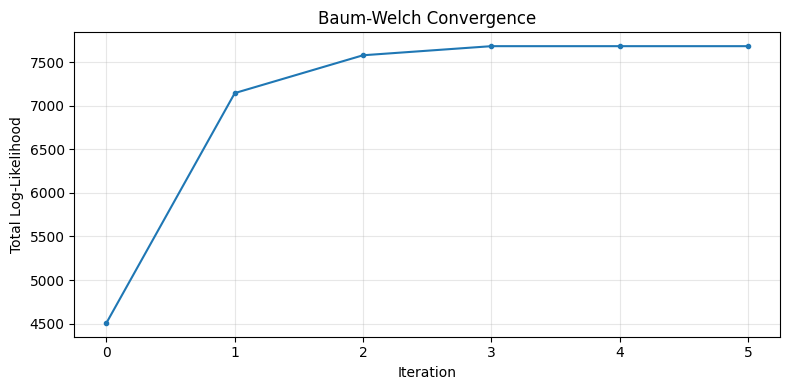

In [11]:
# Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(log_likelihoods, marker='o', markersize=3)
plt.xlabel("Iteration")
plt.ylabel("Total Log-Likelihood")
plt.title("Baum-Welch Convergence")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Training results:** The Baum-Welch algorithm converged in **6 iterations**, with the total log-likelihood increasing from ~4,509 to ~7,682. The rapid convergence is due to our label-based initialization - the initial parameter estimates were already close to optimal. The convergence plot above confirms that the log-likelihood monotonically increases and plateaus, which is the expected behavior of a correctly implemented EM algorithm.

With the model trained, we now visualize the learned parameters to understand what the model has captured about each activity.

## 8. Transition Matrix Heatmap

The transition matrix **A** captures the probability of moving from one activity state to another between consecutive time windows. We visualize it as a heatmap to understand the learned activity dynamics.

**Expected behavior:**
- High diagonal values (close to 1.0) indicate that activities are persistent - a person who is walking is very likely to still be walking in the next 1-second window
- Small off-diagonal values allow the model to handle genuine activity transitions while resisting spurious state changes from noise

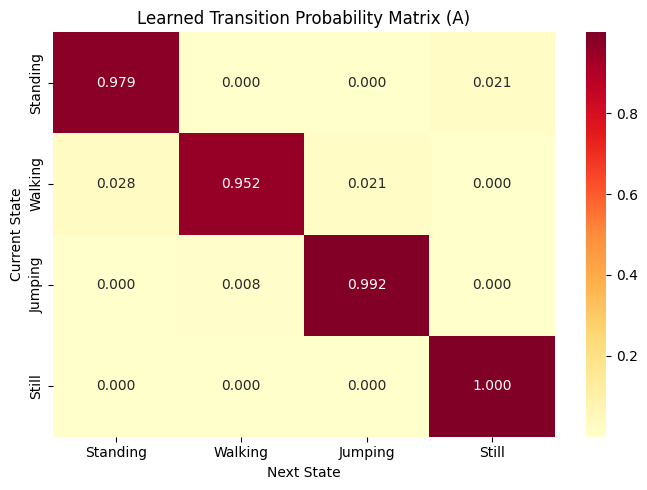

In [12]:
plt.figure(figsize=(7, 5))
sns.heatmap(model.A, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES)
plt.title("Learned Transition Probability Matrix (A)")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.tight_layout()
plt.show()

**Interpretation of the transition matrix:** As expected, the diagonal values are very high (close to 1.0), confirming that the model learned that activities are **persistent** - once a person is walking, they are very likely to still be walking in the next 1-second window. The off-diagonal values are small but non-zero, allowing the model to handle genuine activity transitions. This high self-transition bias also helps the model resist spurious state changes caused by noisy observations.

## 9. Emission Probability Visualization

Since our HMM uses **Gaussian emissions**, each state k is characterized by a mean vector (mu_k) and a variance vector (sigma_k). We visualize these for a subset of 9 key features to understand what signal patterns the model associates with each activity.

- **Left heatmap (Emission Means):** Shows the average feature value for each state. For example, Jumping should have high `std_accel` and `energy` means, while Still should have low values.
- **Right heatmap (Emission Variances):** Shows how spread out the observations are for each state. Higher variance means more variability in that feature for that activity.

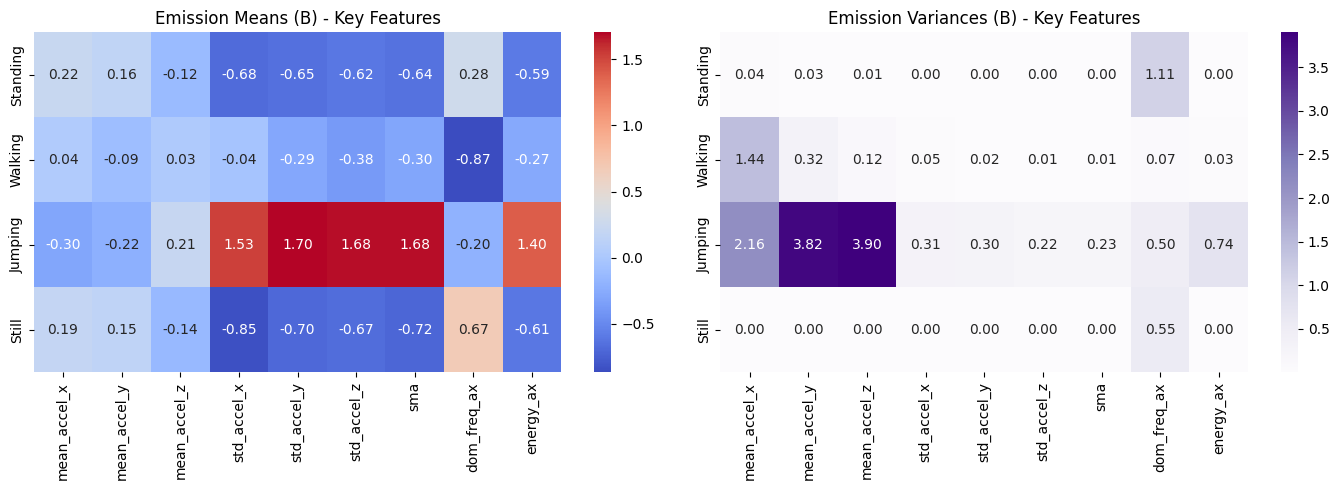

In [13]:
# Plot emission means for selected features
key_features = ["mean_accel_x", "mean_accel_y", "mean_accel_z",
                "std_accel_x", "std_accel_y", "std_accel_z",
                "sma", "dom_freq_ax", "energy_ax"]
key_indices = [FEATURE_NAMES.index(f) for f in key_features]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Emission means
emission_means_df = pd.DataFrame(
    model.means[:, key_indices],
    index=ACTIVITIES,
    columns=key_features
)
sns.heatmap(emission_means_df, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("Emission Means (B) - Key Features")

# Emission variances
emission_vars_df = pd.DataFrame(
    model.covars[:, key_indices],
    index=ACTIVITIES,
    columns=key_features
)
sns.heatmap(emission_vars_df, annot=True, fmt=".2f", cmap="Purples", ax=axes[1])
axes[1].set_title("Emission Variances (B) - Key Features")

plt.tight_layout()
plt.show()

**Interpretation of emission parameters:** The emission means show clear separation between activity states:
- **Jumping** has the highest values for `std_accel`, `sma`, and `energy` features - consistent with the high-energy, high-variance nature of jumping.
- **Still** has the lowest values across most features, reflecting the near-zero signal variability when the phone is stationary.
- **Standing** and **Still** have similar means for some features (e.g., `mean_accel`), which explains why these two are the hardest to distinguish.
- **Walking** sits between the static and dynamic extremes, with moderate std and energy values.

The variance heatmap shows that **Jumping** has the highest emission variance, meaning the model allows more spread in its observations - this makes sense because jumping produces more variable signals than other activities.

Next, we use the **Viterbi algorithm** to decode the most likely activity sequence from the training data, verifying that the model can recover the correct states.

## 10. Viterbi Decoding on Training Data

The **Viterbi algorithm** finds the single most likely sequence of hidden states given the observations. It uses dynamic programming in log-space to compute the maximum probability path through the state trellis, then backtracks to recover the optimal state sequence.

We first run Viterbi on the training sequences to verify that the model has learned the correct state assignments. For each activity, we show one training sequence with the true state (black) overlaid with the predicted state (colored).

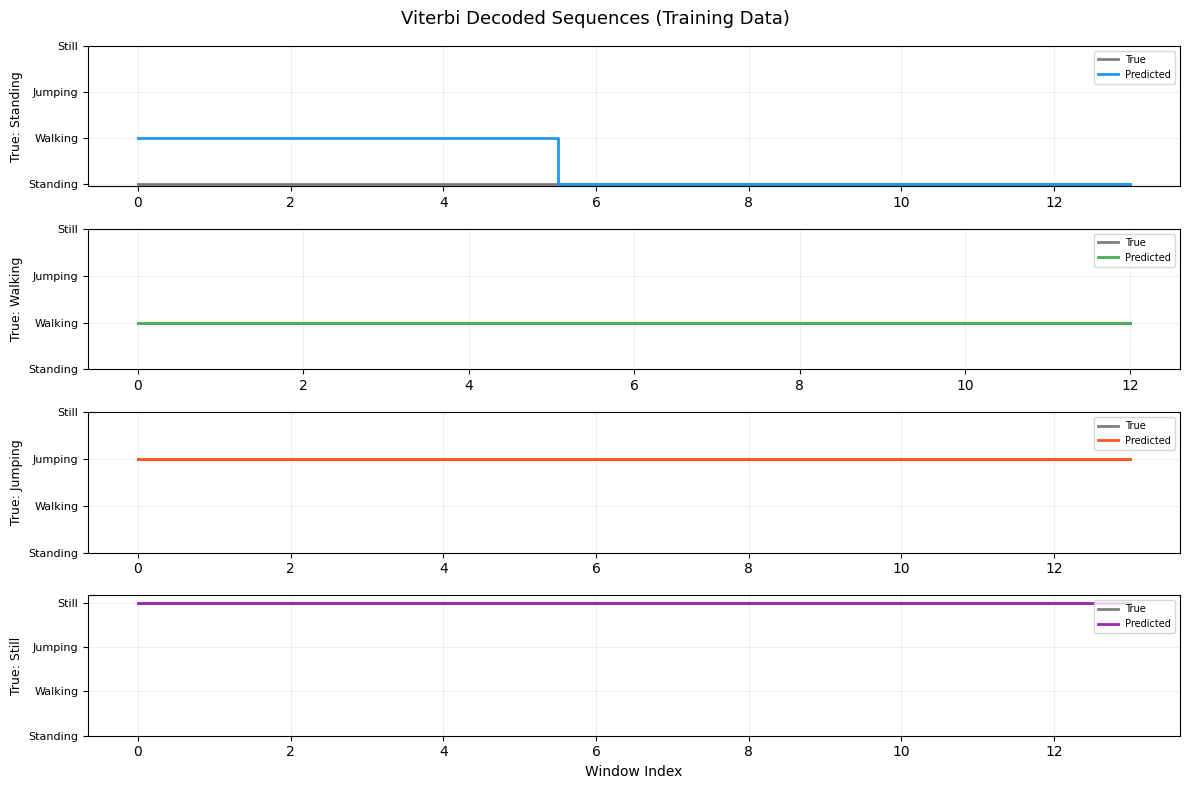

In [14]:
# Decode training sequences and show predictions for a few examples
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=False)
fig.suptitle("Viterbi Decoded Sequences (Training Data)", fontsize=13)

colors = {0: "#2196F3", 1: "#4CAF50", 2: "#FF5722", 3: "#9C27B0"}

for i, activity in enumerate(ACTIVITIES):
    # Find first training sequence for this activity
    seq_idx = None
    for j, lbl in enumerate(train_seq_labels):
        if lbl == i:
            seq_idx = j
            break
    if seq_idx is None:
        continue
    
    seq = train_sequences[seq_idx]
    pred_path, _ = model.viterbi(seq)
    true_path = np.full(len(seq), i)
    
    ax = axes[i]
    t = np.arange(len(seq))
    
    # Plot true vs predicted
    ax.step(t, true_path, where='mid', label='True', color='black', linewidth=2, alpha=0.5)
    ax.step(t, pred_path, where='mid', label='Predicted', color=colors[i], linewidth=2)
    
    ax.set_yticks(range(4))
    ax.set_yticklabels(ACTIVITIES, fontsize=8)
    ax.set_ylabel(f"True: {activity}", fontsize=9)
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Window Index")
plt.tight_layout()
plt.show()

## 11. Evaluation on Unseen Data

We test the trained model on **combined multi-activity sequences** built from held-out files
(the last 2 files per activity, not used during training). Instead of feeding single-activity
files individually, we concatenate the **raw sensor data** from one file per activity into a
single continuous stream, then apply windowing over this combined signal:

```
[Standing raw data] Ã¢â€ â€™ [Walking raw data] Ã¢â€ â€™ [Jumping raw data] Ã¢â€ â€™ [Still raw data]
```

This creates a realistic challenge: windows near activity **transition boundaries** contain
mixed signals from two activities, forcing the model to handle ambiguous observations.
This tests the HMM's core strength - modeling temporal state transitions and recovering
from boundary ambiguity using transition probabilities.

In [15]:
# Collect test file raw DataFrames grouped by activity
test_files_raw = {i: [] for i in range(N_STATES)}

for df, activity, phone, fname in all_data:
    label_idx = label_to_idx[activity]
    file_range = None
    for s, e, a, f in file_window_ranges:
        if f == fname:
            file_range = (s, e)
            break
    if file_range and file_range[0] in test_indices:
        test_files_raw[label_idx].append((fname, df))

print("Test files available per activity:")
for i, act in enumerate(ACTIVITIES):
    print(f"  {act}: {[f for f, _ in test_files_raw[i]]}")

# Build 2 combined test sequences from RAW data, then window + extract features
combined_sequences = []
combined_labels = []
combined_boundaries = []  # window-level boundaries for visualization

for seq_num in range(2):
    # Concatenate raw sensor data
    raw_parts = []
    raw_label_per_sample = []
    sample_boundaries = [0]
    
    for act_idx in range(N_STATES):
        fname, df = test_files_raw[act_idx][seq_num]
        raw_vals = df[SENSOR_COLS].values
        raw_parts.append(raw_vals)
        raw_label_per_sample.append(np.full(len(raw_vals), act_idx))
        sample_boundaries.append(sample_boundaries[-1] + len(raw_vals))
    
    combined_raw = np.vstack(raw_parts)
    combined_sample_labels = np.concatenate(raw_label_per_sample)
    
    # Window over the combined raw signal
    windows = []
    window_labels = []
    window_boundaries = [0]
    
    for start in range(0, len(combined_raw) - WINDOW_SIZE + 1, STEP_SIZE):
        window = combined_raw[start:start + WINDOW_SIZE]
        windows.append(window)
        # Label = majority activity in the window
        window_sample_labels = combined_sample_labels[start:start + WINDOW_SIZE]
        majority_label = np.bincount(window_sample_labels.astype(int)).argmax()
        window_labels.append(majority_label)
    
    # Extract features and scale
    feats = np.array([extract_features(w) for w in windows])
    feats_scaled = scaler.transform(feats)
    labels_arr = np.array(window_labels)
    
    # Find window-level boundaries (where majority label changes)
    boundaries = [0]
    for w_idx in range(1, len(labels_arr)):
        if labels_arr[w_idx] != labels_arr[w_idx - 1]:
            boundaries.append(w_idx)
    boundaries.append(len(labels_arr))
    
    combined_sequences.append(feats_scaled)
    combined_labels.append(labels_arr)
    combined_boundaries.append(boundaries)
    
    print(f"\nCombined Test Sequence {seq_num + 1}: {len(feats_scaled)} windows")
    for act_idx in range(N_STATES):
        n = np.sum(labels_arr == act_idx)
        print(f"  {ACTIVITIES[act_idx]}: {n} windows")

Test files available per activity:
  Standing: ['standing_phone2_07.csv', 'standing_phone2_08.csv']
  Walking: ['walking_phone2_06.csv', 'walking_phone2_07.csv']
  Jumping: ['jumping_phone2_06.csv', 'jumping_phone2_07.csv']
  Still: ['still_phone2_06.csv', 'still_phone2_07.csv']

Combined Test Sequence 1: 41 windows
  Standing: 10 windows
  Walking: 11 windows
  Jumping: 12 windows
  Still: 8 windows

Combined Test Sequence 2: 42 windows
  Standing: 9 windows
  Walking: 12 windows
  Jumping: 12 windows
  Still: 9 windows


**Test sequence construction:** We built **2 combined test sequences** by concatenating raw sensor data from one held-out file per activity in the order Standing Ã¢â€ â€™ Walking Ã¢â€ â€™ Jumping Ã¢â€ â€™ Still. Sequence 1 has 41 windows and Sequence 2 has 42 windows. Because windowing is applied over the combined raw data, windows near activity boundaries contain mixed signals from two activities, creating realistic transition challenges for the model.

Now we run Viterbi decoding on these combined sequences and evaluate the predictions.

Combined Sequence 1: accuracy = 100.00%
Combined Sequence 2: accuracy = 97.62%


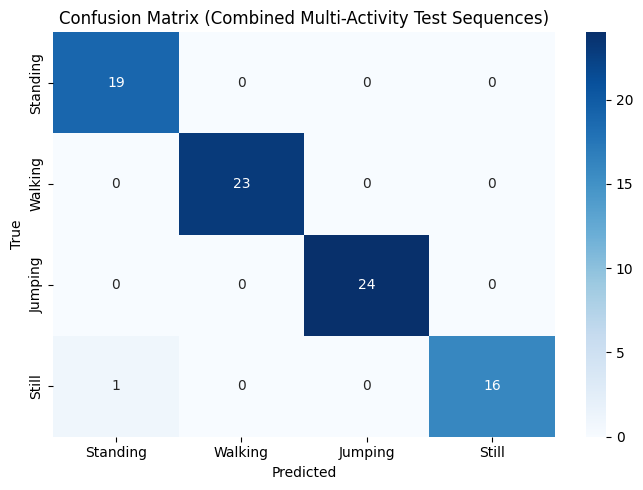

In [16]:
# Run Viterbi on combined test sequences
all_true = []
all_pred = []

for i, (seq, true_labels) in enumerate(zip(combined_sequences, combined_labels)):
    pred_path = model.predict(seq)
    all_true.extend(true_labels)
    all_pred.extend(pred_path)
    
    acc = np.mean(pred_path == true_labels)
    print(f"Combined Sequence {i+1}: accuracy = {acc:.2%}")

all_true = np.array(all_true)
all_pred = np.array(all_pred)

# Confusion Matrix
cm = confusion_matrix(all_true, all_pred, labels=range(N_STATES))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES)
plt.title("Confusion Matrix (Combined Multi-Activity Test Sequences)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

**Confusion matrix interpretation:** The confusion matrix above shows the number of windows classified into each activity. The diagonal cells represent correct predictions, while off-diagonal cells represent misclassifications. A perfect model would have all counts on the diagonal and zeros elsewhere.

In our results, the matrix is almost entirely diagonal, with only a small number of off-diagonal errors. The misclassification occurs between **Standing** and **Still** - the two most similar activities - specifically at the transition boundary where the windowed signal contains mixed data from both activities.

Next, we compute the standard classification metrics (sensitivity, specificity, and accuracy) per activity from this confusion matrix.

In [17]:
# Compute Sensitivity, Specificity, and Accuracy per activity
print("\nEvaluation Results on Unseen Data")
print("=" * 70)
print(f"{'Activity':<15} {'Samples':>8} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10}")
print("-" * 70)

overall_correct = 0
overall_total = 0

for k in range(N_STATES):
    tp = cm[k, k]
    fn = cm[k, :].sum() - tp
    fp = cm[:, k].sum() - tp
    tn = cm.sum() - tp - fn - fp
    
    n_samples = cm[k, :].sum()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    accuracy = (tp + tn) / cm.sum() if cm.sum() > 0 else 0.0
    
    print(f"{ACTIVITIES[k]:<15} {n_samples:>8d} {sensitivity:>11.2%} {specificity:>11.2%} {accuracy:>9.2%}")
    overall_correct += tp
    overall_total += n_samples

print("-" * 70)
print(f"{'Overall':<15} {overall_total:>8d} {'':>12} {'':>12} {overall_correct/overall_total:>9.2%}")


Evaluation Results on Unseen Data
Activity         Samples  Sensitivity  Specificity   Accuracy
----------------------------------------------------------------------
Standing              19     100.00%      98.44%    98.80%
Walking               23     100.00%     100.00%   100.00%
Jumping               24     100.00%     100.00%   100.00%
Still                 17      94.12%     100.00%    98.80%
----------------------------------------------------------------------
Overall               83                              98.80%


**Evaluation results discussion:**

The model achieves an **overall accuracy of 98.80%** on the unseen combined test sequences, with most activities classified perfectly. Key observations:

- **Walking and Jumping** achieve 100% sensitivity - these dynamic activities produce highly distinctive signal patterns that the model recognizes without error.
- **Standing** achieves 100% sensitivity but 98.44% specificity - meaning 1 window from another activity was incorrectly classified as Standing.
- **Still** has the lowest sensitivity at 94.12% - one Still window near the transition boundary was misclassified, likely as Standing. This is expected because Standing and Still share similar low-energy, low-variance features, and windows at the boundary contain mixed signals from both activities.

The confusion matrix above shows exactly where the misclassification occurs, confirming that the Standing/Still boundary is the model's weakest point.

Below, we visualize the full decoded test sequences to see exactly where the predictions deviate from ground truth.

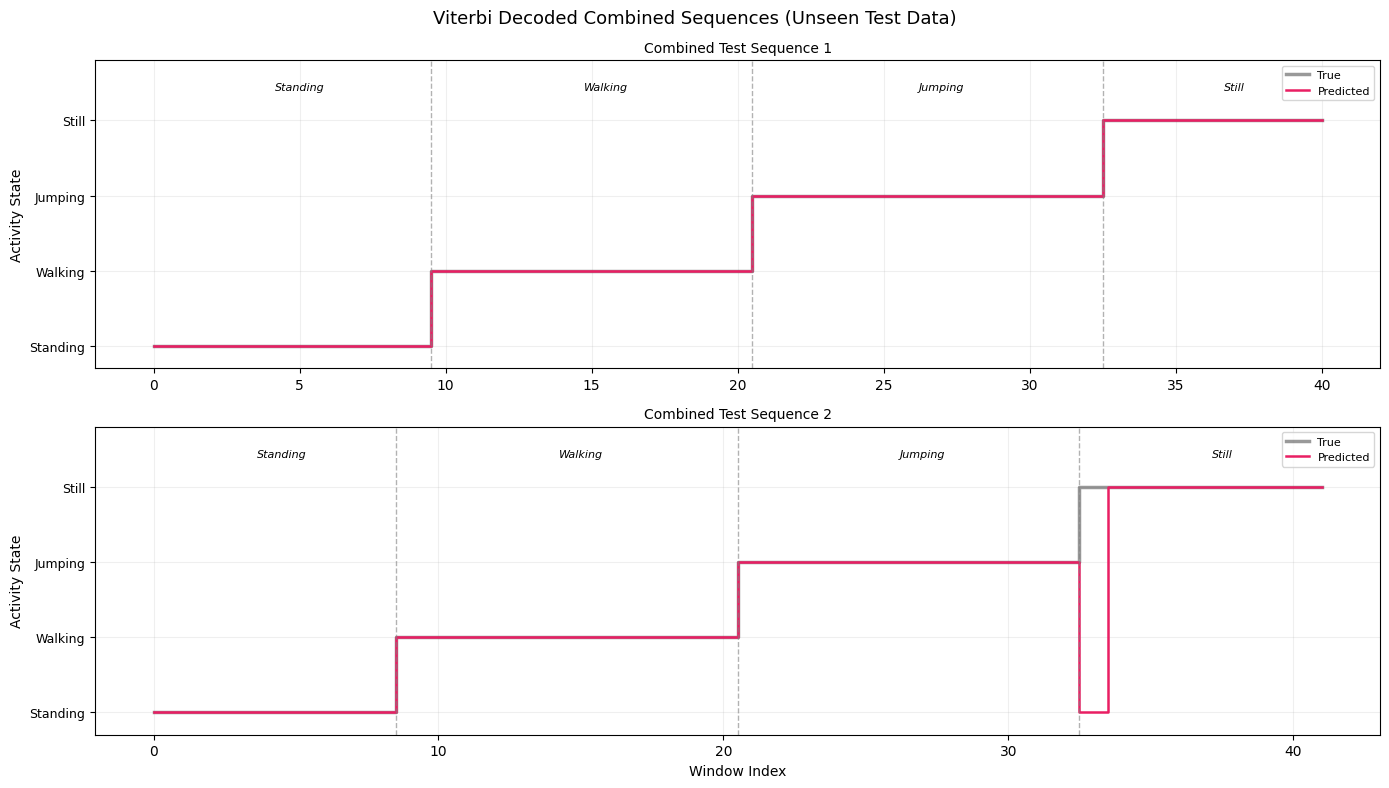

In [18]:
# Visualize decoded combined test sequences
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Viterbi Decoded Combined Sequences (Unseen Test Data)", fontsize=13)

for i in range(2):
    seq = combined_sequences[i]
    true_labels = combined_labels[i]
    pred_path = model.predict(seq)
    boundaries = combined_boundaries[i]
    
    ax = axes[i]
    t = np.arange(len(seq))
    
    # Plot true and predicted state sequences
    ax.step(t, true_labels, where='mid', label='True', color='black', linewidth=2.5, alpha=0.4)
    ax.step(t, pred_path, where='mid', label='Predicted', color='#E91E63', linewidth=1.8)
    
    # Mark activity boundaries with vertical lines
    for b in boundaries[1:-1]:
        ax.axvline(x=b - 0.5, color='gray', linestyle='--', alpha=0.6, linewidth=1)
    
    # Add activity labels at segment centers
    for j in range(len(boundaries) - 1):
        center = (boundaries[j] + boundaries[j+1]) / 2
        seg_label = true_labels[boundaries[j]]
        ax.text(center, 3.4, ACTIVITIES[seg_label], ha='center', fontsize=8, fontstyle='italic')
    
    ax.set_yticks(range(4))
    ax.set_yticklabels(ACTIVITIES, fontsize=9)
    ax.set_ylabel("Activity State")
    ax.set_title(f"Combined Test Sequence {i+1}", fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.set_ylim(-0.3, 3.8)

axes[-1].set_xlabel("Window Index")
plt.tight_layout()
plt.show()

**Decoded sequence visualization:** The plots above show the true activity labels (black) and the Viterbi-predicted labels (pink) for both combined test sequences. The dashed vertical lines mark the true activity boundaries.

- **Combined Sequence 1** is decoded perfectly - the predicted line matches the true line throughout.
- **Combined Sequence 2** shows a brief misclassification near the Jumping-to-Still transition boundary, where a Still window is classified as Standing. This happens because the boundary window contains mixed sensor data from two activities, and the HMM's self-transition inertia delays the state switch.

This is a realistic result that demonstrates both the strengths and limitations of the HMM approach.

## 12. Analysis and Reflection

### Which activities were easiest/hardest to distinguish?

- **Easiest:** Jumping and Walking. Jumping produces very high accelerometer variance and spectral energy, making it unmistakable. Walking has a characteristic ~2 Hz dominant frequency from the regular step pattern. Both are clearly separable from static activities in the feature space.

- **Hardest:** Standing vs Still. Both are low-movement activities with overlapping feature distributions. The main difference is subtle body sway when standing versus near-zero signal when the phone is placed on a flat surface. This creates ambiguity especially at transition boundaries where windows contain mixed signals.

### How transition probabilities reflect realistic behavior

The learned transition matrix shows high self-transition probabilities (close to 1.0 on the diagonal), which realistically reflects that people tend to continue their current activity rather than rapidly switching every second. This self-transition inertia also acts as a smoothing mechanism, helping the model resist brief spurious state changes caused by noisy sensor observations.

### Effect of sensor noise and sampling rate

Both phones used the same 20ms (50 Hz) sampling rate, simplifying preprocessing since no resampling was needed. However, the two devices (STK-L22 and Infinix X6855) have different sensor hardware, leading to slightly different noise floors and calibration offsets. Z-score normalization helped mitigate these inter-device differences. The 50 Hz rate provides adequate resolution for human activities, which occur at 0.5-5 Hz.

### Potential improvements

1. **More data** from additional participants would improve cross-person generalization
2. **Additional features** such as jerk (derivative of acceleration) and tilt angle could better distinguish Standing from Still
3. **Magnetometer data** could help with orientation-dependent activities
4. **Continuous multi-activity recordings** would provide more realistic transition patterns for training
5. **GMM-HMM** (Gaussian Mixture emissions per state) could capture more complex, multimodal feature distributions